<a href="https://colab.research.google.com/github/mahiiipathak/ML-LAB-/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- SVM Accuracy Comparison ---
Linear Kernel Accuracy: 0.8250
RBF Kernel Accuracy   : 0.9500

Support Vectors (Linear): 60
Support Vectors (RBF)   : 46


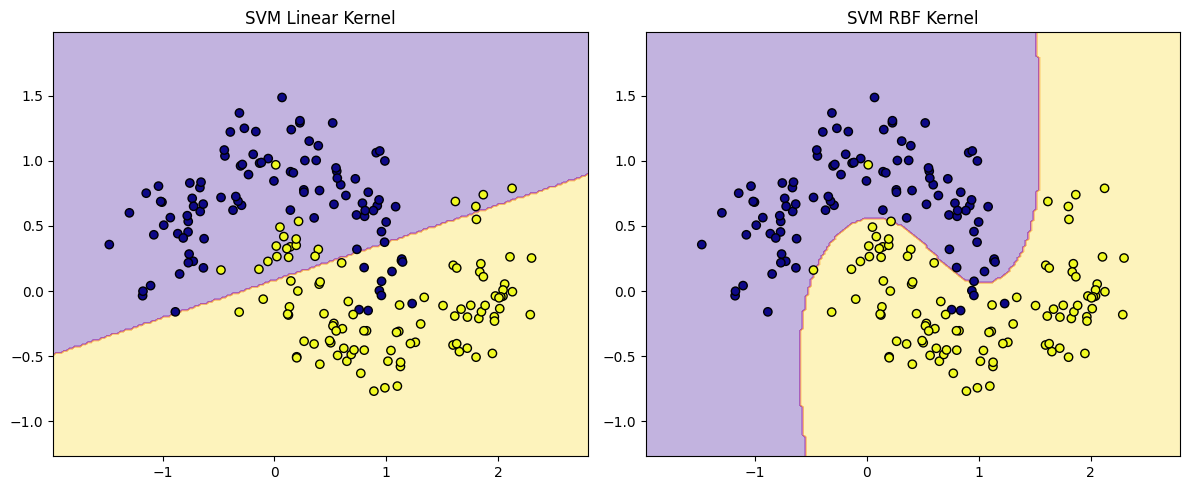

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Load/Generate synthetic_moons dataset
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Linear Kernel SVM
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

# 3. Train RBF Kernel SVM
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

# 4. Compare accuracies
acc_lin = accuracy_score(y_test, svm_linear.predict(X_test))
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test))

print("--- SVM Accuracy Comparison ---")
print(f"Linear Kernel Accuracy: {acc_lin:.4f}")
print(f"RBF Kernel Accuracy   : {acc_rbf:.4f}")

# 5. Display number of support vectors
print(f"\nSupport Vectors (Linear): {len(svm_linear.support_vectors_)}")
print(f"Support Vectors (RBF)   : {len(svm_rbf.support_vectors_)}")

# 6. Plot decision boundaries
def plot_boundary(clf, title, subplot_idx):
    plt.subplot(1, 2, subplot_idx)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='plasma')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='plasma', edgecolors='k')
    plt.title(title)

plt.figure(figsize=(12, 5))
plot_boundary(svm_linear, "SVM Linear Kernel", 1)
plot_boundary(svm_rbf, "SVM RBF Kernel", 2)
plt.tight_layout()
plt.show()